In [5]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("algozee/teenager-menthal-healy")

print("Path to dataset files:", path)

100%|██████████| 15.8k/15.8k [00:00<00:00, 1.22MB/s]

Extracting files...
Path to dataset files: /Users/quannguyen/.cache/kagglehub/datasets/algozee/teenager-menthal-healy/versions/1


In [1]:
import numpy as np
import pandas as pd

import os 
for dirname, _, filenames in os.walk('/kaggle/input'):
  for filename in filenames:
    print(os.join.path(dirname, filename))

/var/folders/ql/s803k9yn2l570nz7shf781y80000gn/T/ipykernel_57588/926834298.py:2: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
import numpy as np 
import pandas as pd 
import seaborn as sns
from sklearn .decomposition import PCA 
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

In [8]:
data = pd.read_csv('/Users/quannguyen/Documents/ScikitLearn-TensorFlow Tutorial/Chapter_02/datasets/social-media-teen-mental-health/Teen_Mental_Health_Dataset.csv')

In [9]:
data.head()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


In [20]:
data.describe()

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,15.928333,4.536667,6.449417,1.740333,2.990383,1.014500,1.961667,5.445833,5.636667,5.565000,0.025833
std,2.021947,2.029599,1.442677,0.716660,0.576758,0.582185,0.807718,2.903290,2.859453,2.830627,0.158704
min,13.000000,1.000000,4.000000,0.500000,2.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,14.000000,2.800000,5.200000,1.100000,2.500000,0.500000,1.000000,3.000000,3.000000,3.000000,0.000000
50%,16.000000,4.500000,6.500000,1.800000,2.990000,1.000000,2.000000,5.000000,6.000000,6.000000,0.000000
75%,18.000000,6.300000,7.600000,2.400000,3.480000,1.500000,3.000000,8.000000,8.000000,8.000000,0.000000
max,19.000000,8.000000,9.000000,3.000000,4.000000,2.000000,3.000000,10.000000,10.000000,10.000000,1.000000


In [21]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   object 
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   object 
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   int64  
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(6), object(2)
memory usage: 122.0+ KB


In [22]:
data.isnull().sum()

age                         0
gender                      0
daily_social_media_hours    0
platform_usage              0
sleep_hours                 0
screen_time_before_sleep    0
academic_performance        0
physical_activity           0
social_interaction_level    0
stress_level                0
anxiety_level               0
addiction_level             0
depression_label            0
dtype: int64

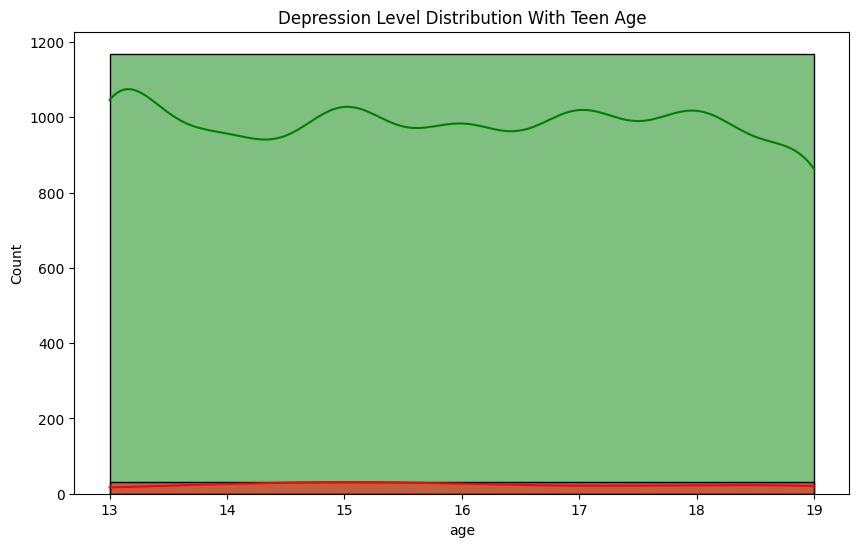

In [18]:
plt.figure(figsize=(10,6))
sns.histplot(data[data['depression_label'] == 0]['age'], bins=1, color='green', label='No drepress', kde=True)
sns.histplot(data[data['depression_label'] == 1]['age'], bins=1, color='red', label='drepress', kde=True)
plt.title("Depression Level Distribution With Teen Age")
plt.show()

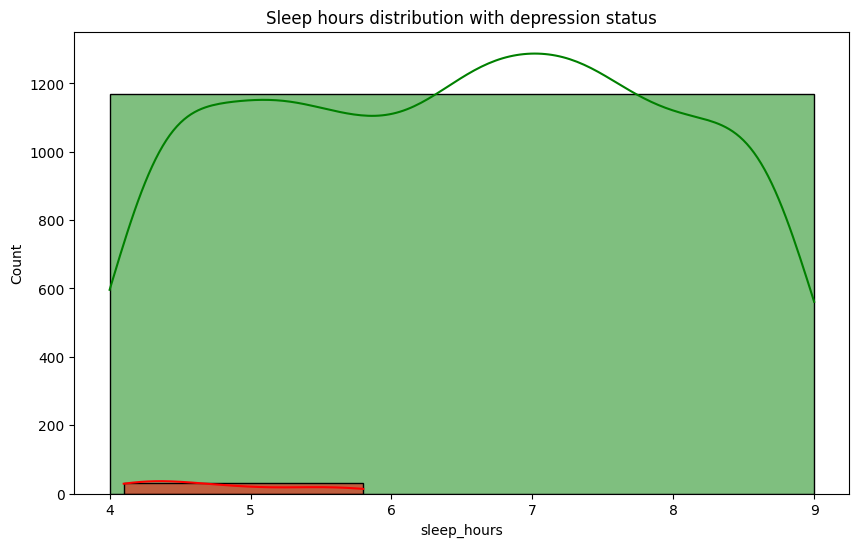

In [19]:
plt.figure(figsize=(10,6))
sns.histplot(data[data['depression_label']==0]['sleep_hours'], bins=1, color='green', label='No depress', kde=True)
sns.histplot(data[data['depression_label']==1]['sleep_hours'], bins=1, color='red', label='Depress', kde=True)
plt.title("Sleep hours distribution with depression status")
plt.show()

Text(0.5, 1.0, 'Correlation Matrix of Figures')

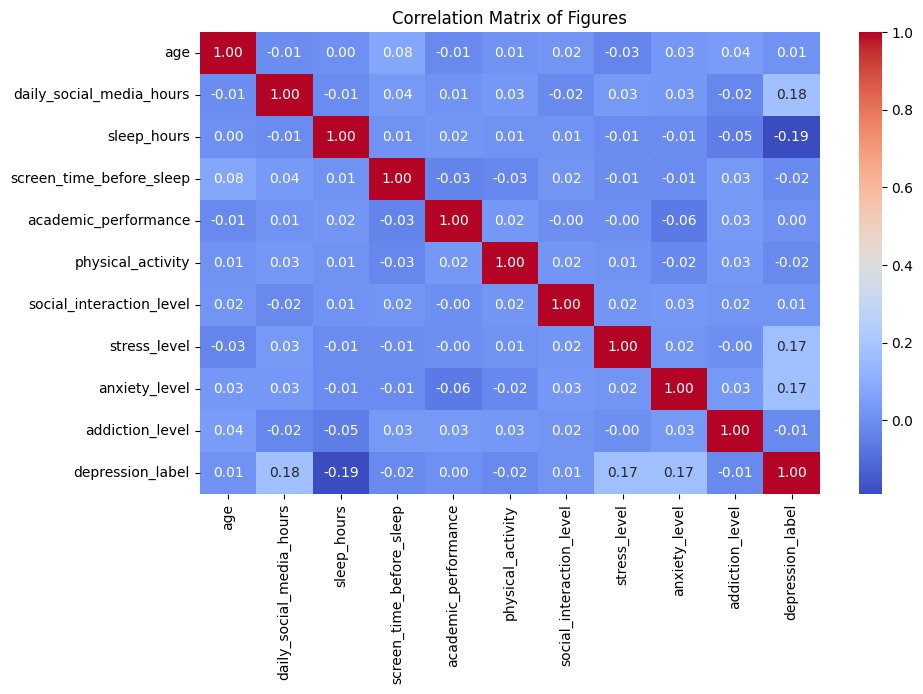

In [24]:
numeric_data = data.select_dtypes(include=['float64', 'int64'])
correlation_matrix = numeric_data.corr()
plt.figure(figsize=(10,6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Figures')

In [25]:
depression_counts = data['depression_label'].value_counts(normalize=True) * 100
print("Depression Label Percentage: \n", depression_counts)

Depression Label Percentage: 
 depression_label
0    97.416667
1     2.583333
Name: proportion, dtype: float64


In [27]:
platform_stats = data.groupby('platform_usage')[['stress_level', 'anxiety_level', 'addiction_level', 'depression_label']].mean()
print("\nAverage Mental Health Metrics by Platform Usage:")
print(platform_stats)


Average Mental Health Metrics by Platform Usage:
                stress_level  anxiety_level  addiction_level  depression_label
platform_usage                                                                
Both                5.549872       5.488491         5.496164          0.023018
Instagram           5.498783       5.669100         5.581509          0.024331
TikTok              5.288945       5.748744         5.615578          0.030151


Text(0.5, 1.0, 'Daily Social Media Hours vs Stress Level')

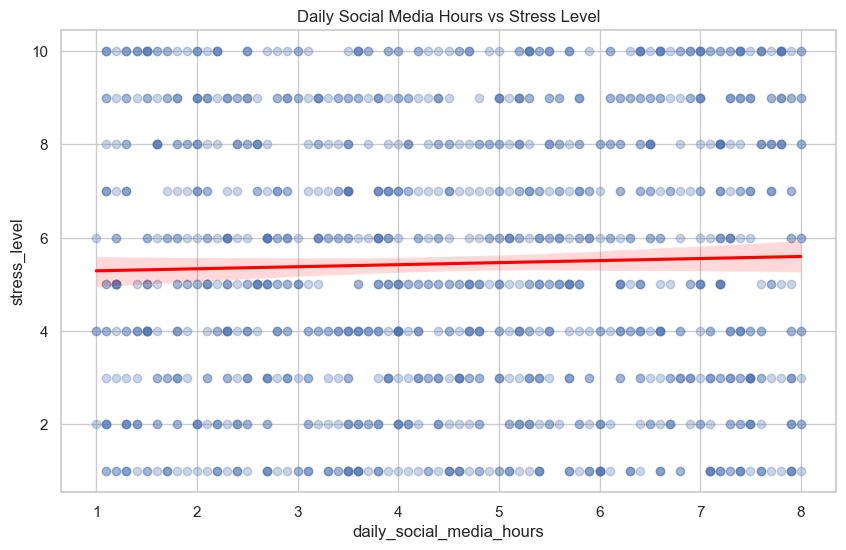

In [29]:
# Set aesthetic style
sns.set_theme(style="whitegrid")

# 1. Social Media Hours vs Stress Level
plt.figure(figsize=(10, 6))
sns.regplot(data=data, x='daily_social_media_hours', y='stress_level', scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Daily Social Media Hours vs Stress Level')

Text(0.5, 1.0, 'Sleep Hours vs Stress Level')

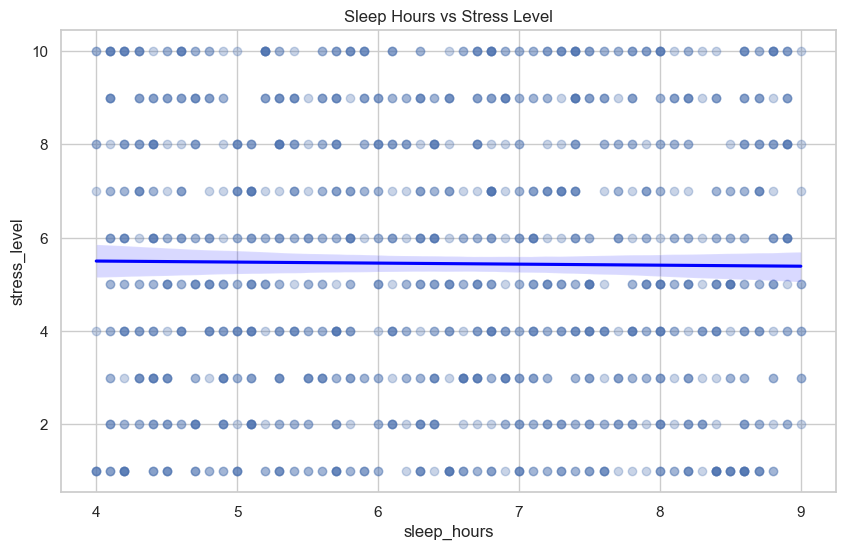

In [32]:
plt.figure(figsize=(10, 6))
sns.regplot(data=data, x='sleep_hours', y='stress_level', scatter_kws={'alpha':0.3}, line_kws={'color':'blue'})
plt.title('Sleep Hours vs Stress Level')

Text(0.5, 1.0, 'Anxiety Level by Platform Usage')

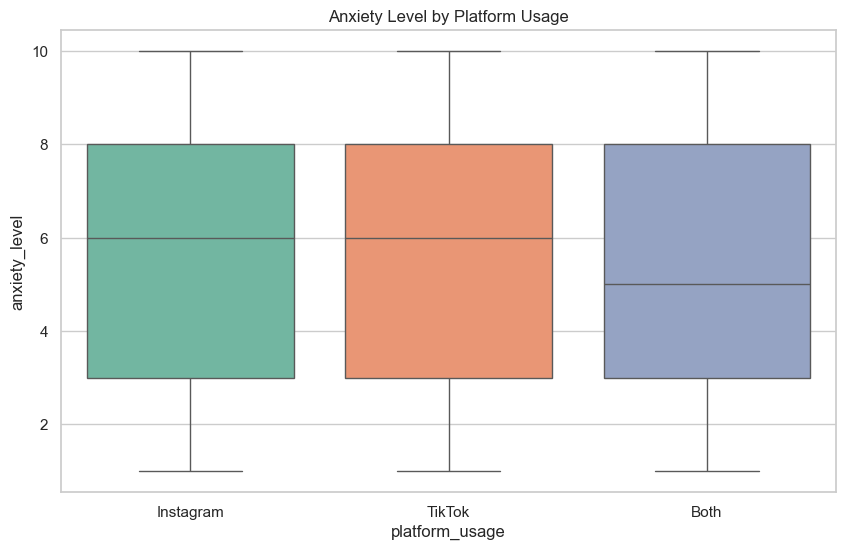

In [33]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='platform_usage', y='anxiety_level', hue='platform_usage', palette='Set2', legend=False)
plt.title('Anxiety Level by Platform Usage')

Text(0.5, 1.0, 'Average Stress Level by Social Interaction Level')

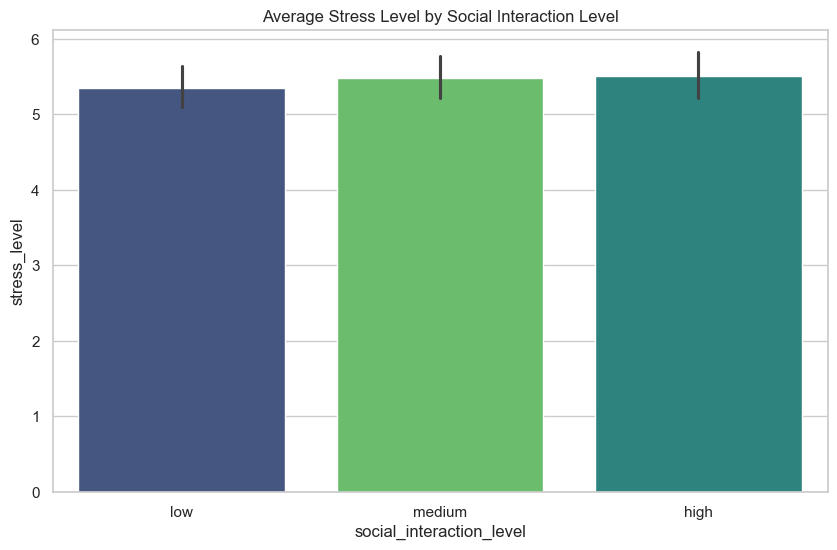

In [34]:
# 4. Stress Level by Social Interaction Level
plt.figure(figsize=(10, 6))
order = ['low', 'medium', 'high']
sns.barplot(data=df, x='social_interaction_level', y='stress_level', order=order, hue='social_interaction_level', palette='viridis', legend=False)
plt.title('Average Stress Level by Social Interaction Level')

Text(0.5, 1.0, 'Age Distribution by Gender')

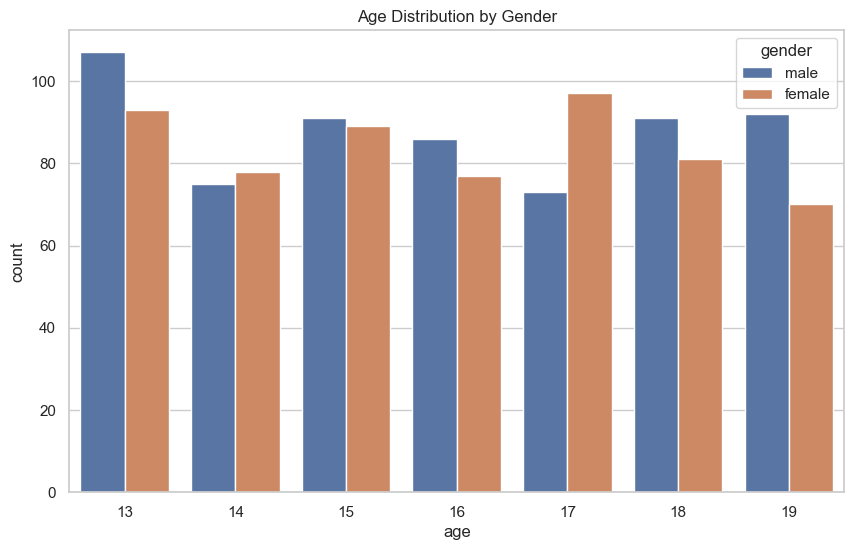

In [35]:
# Distribution of ages
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='age', hue='gender')
plt.title('Age Distribution by Gender')

In [37]:
# Social interaction vs depression
interaction_depression = pd.crosstab(data['social_interaction_level'], data['depression_label'], normalize='index') * 100
print("\nDepression Percentage by Social Interaction Level:")
print(interaction_depression)


Depression Percentage by Social Interaction Level:
depression_label                  0         1
social_interaction_level                     
1                         97.831325  2.168675
2                         97.115385  2.884615
3                         97.289973  2.710027
